<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L02-Nociones_TS/notebooks/L02_ModelosIniciales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ruido Blanco**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Valor semilla para replicar resultados
np.random.seed(100)

In [2]:
# Crear 1000 puntos de una distribución normal estándar
w = np.random.randn(1000)
dfModelos = pd.DataFrame(w, columns=['w'])
dfModelos.head(10)

,w
0,-1.749765
1,0.342680
2,1.153036
3,-0.252436
4,0.981321
5,0.514219
6,0.221180
7,-1.070043
8,-0.189496
9,0.255001


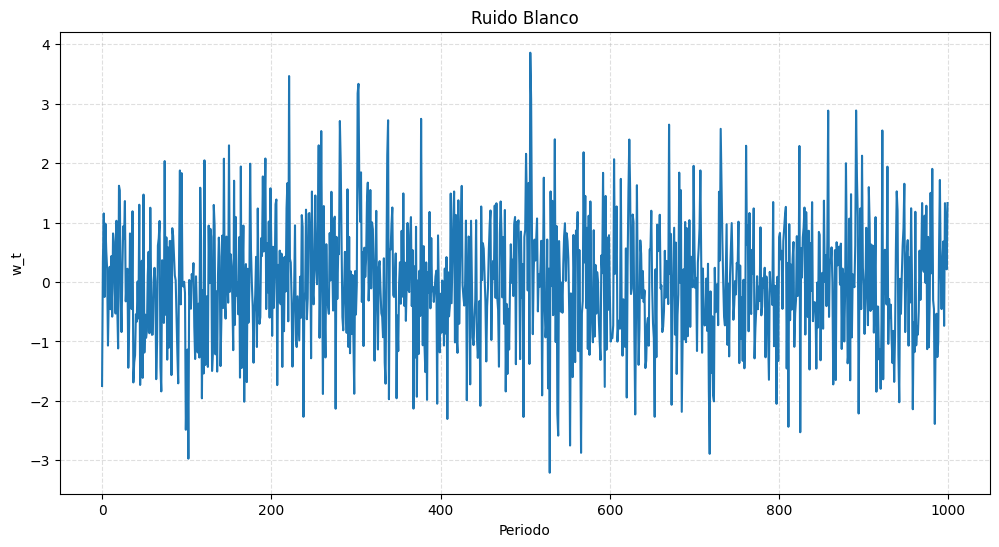

In [3]:
plt.figure(figsize=(12, 6))
dfModelos['w'].plot()

# Etiquetas
plt.title('Ruido Blanco')
plt.xlabel('Periodo')
plt.ylabel('w_t')

# Formato adicional
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

<Figure size 1200x600 with 0 Axes>

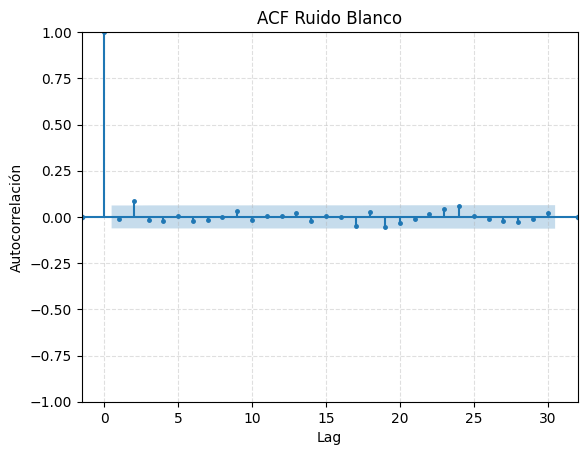

In [4]:
plt.figure(figsize=(12, 6))
# Gráfico de autocorrelación
plot_acf(dfModelos['w'], lags=30, marker = '.')

# Etiquetas
plt.title('ACF Ruido Blanco')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')

# Formato
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

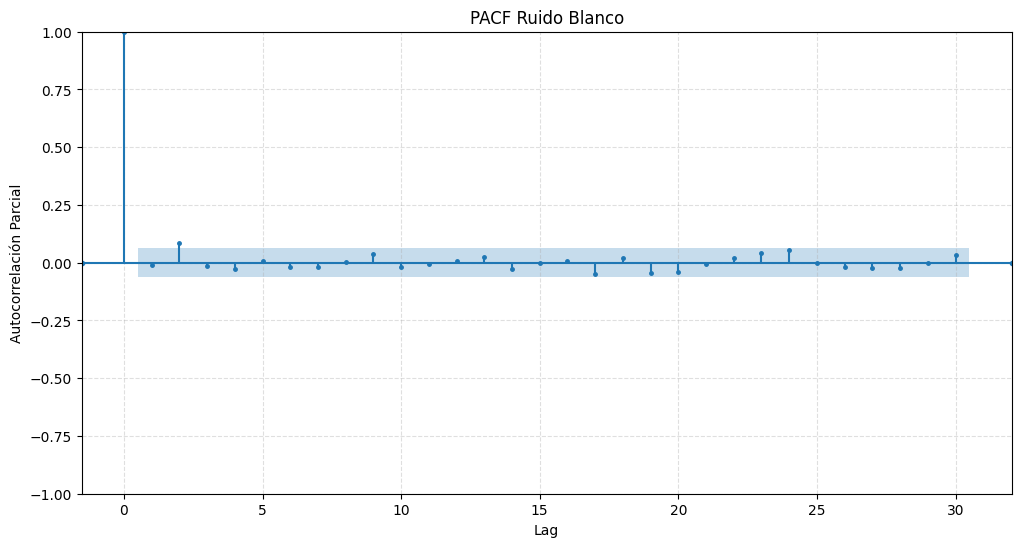

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
# Gráfico de autocorrelación
plot_pacf(dfModelos['w'], lags=30, ax=ax, marker = '.')

# Etiquetas
ax.set_title('PACF Ruido Blanco')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelación Parcial')

# Formato
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [6]:
# plt.figure(figsize=(12,6))
# sns.histplot(dfModelos['w'], kde=True, bins=30)
# plt.title('Distribución de puntos w_t')
# plt.xlabel('Valor')
# plt.ylabel('Frecuencia')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

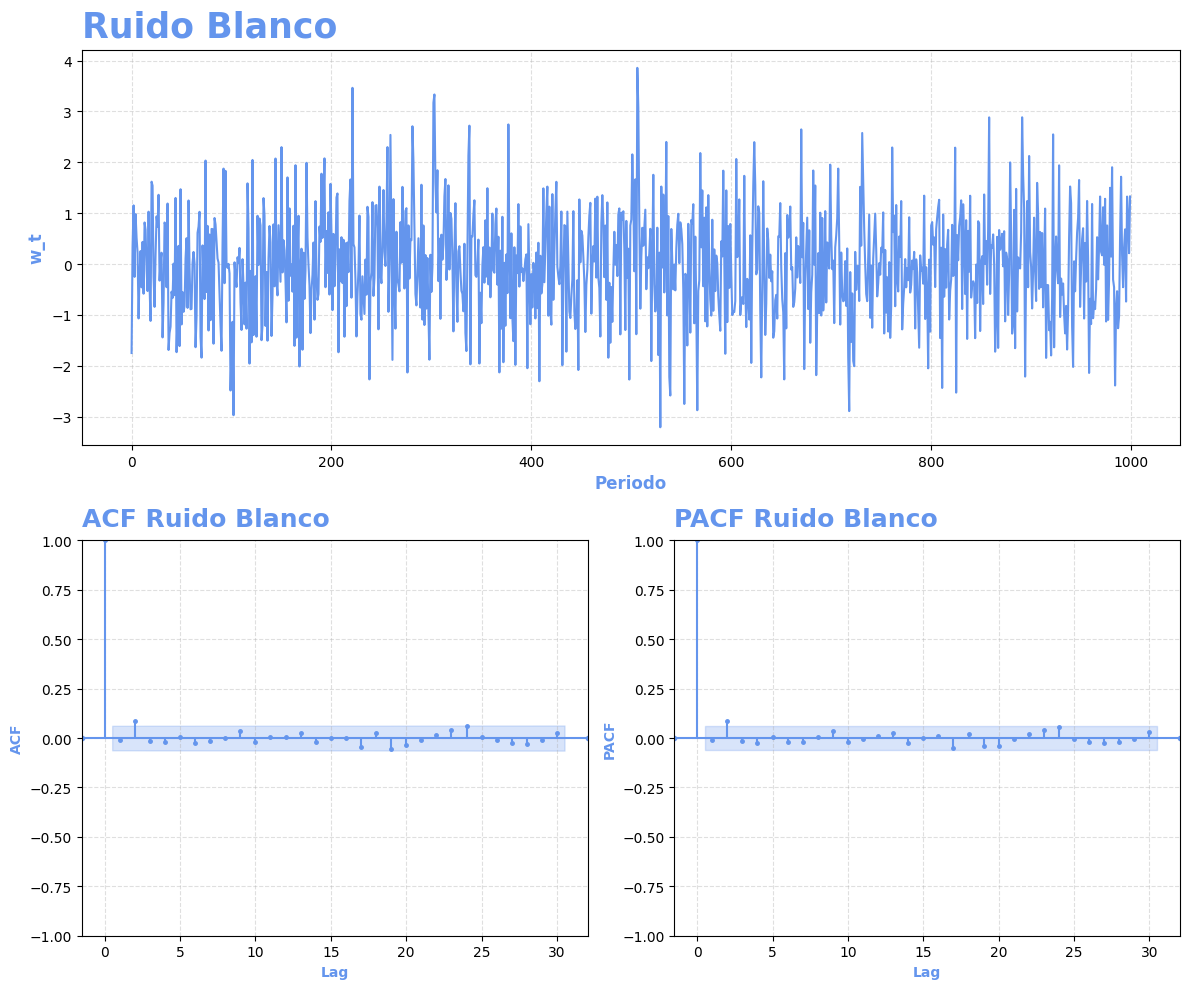

In [7]:
graphColor = 'cornflowerblue'
modelo = 'w'
nombre = 'Ruido Blanco'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
dfModelos[modelo].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('w_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(dfModelos[modelo], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(dfModelos[modelo], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

# **Caminata Aleatoria**

In [8]:
# Crear Caminata mediante suma acumulativa
dfModelos['walk'] = dfModelos['w'].cumsum()
dfModelos.head(10)

,w,walk
0,-1.749765,-1.749765
1,0.342680,-1.407085
2,1.153036,-0.254049
3,-0.252436,-0.506485
4,0.981321,0.474835
5,0.514219,0.989054
6,0.221180,1.210234
7,-1.070043,0.140191
8,-0.189496,-0.049305
9,0.255001,0.205696


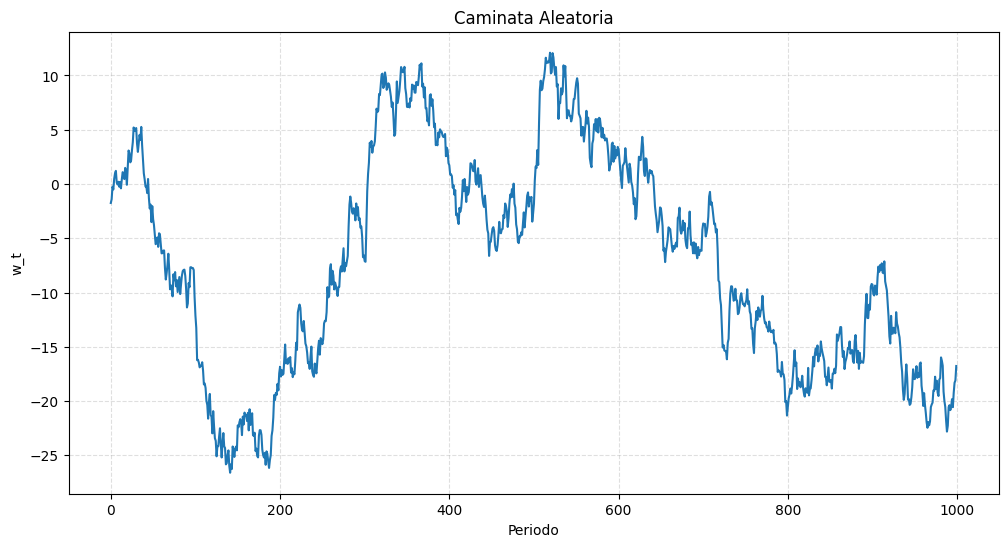

In [9]:
plt.figure(figsize=(12, 6))
dfModelos['walk'].plot()

# Etiquetas
plt.title('Caminata Aleatoria')
plt.xlabel('Periodo')
plt.ylabel('w_t')

# Formato adicional
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

<Figure size 1200x600 with 0 Axes>

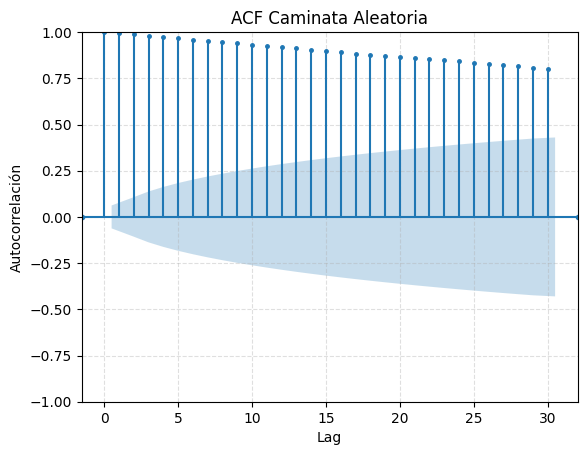

In [10]:
plt.figure(figsize=(12, 6))
# Gráfico de autocorrelación
plot_acf(dfModelos['walk'], lags=30, marker = '.')

# Etiquetas
plt.title('ACF Caminata Aleatoria')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')

# Formato
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

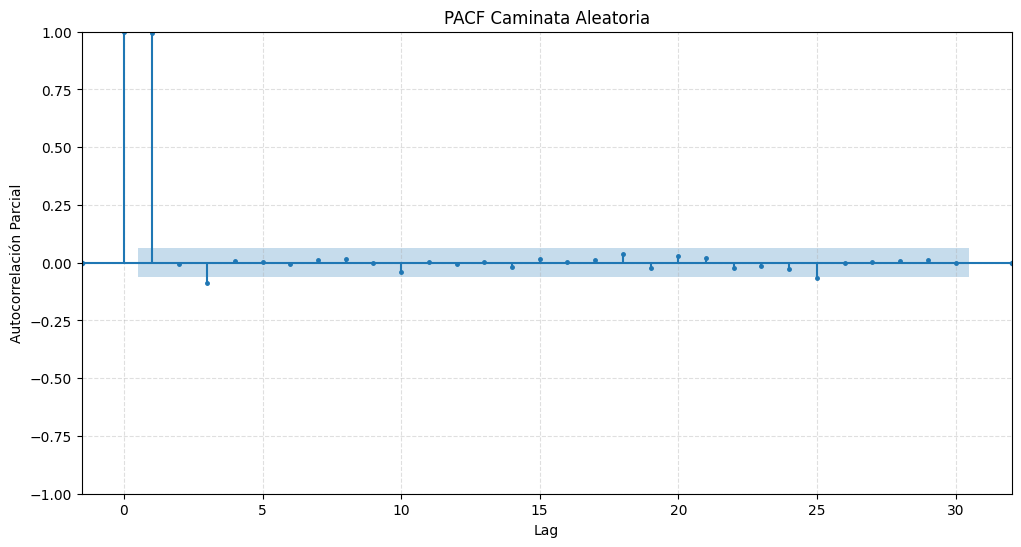

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
# Gráfico de autocorrelación
plot_pacf(dfModelos['walk'], lags=30, ax=ax, marker = '.')

# Etiquetas
ax.set_title('PACF Caminata Aleatoria')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelación Parcial')

# Formato
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

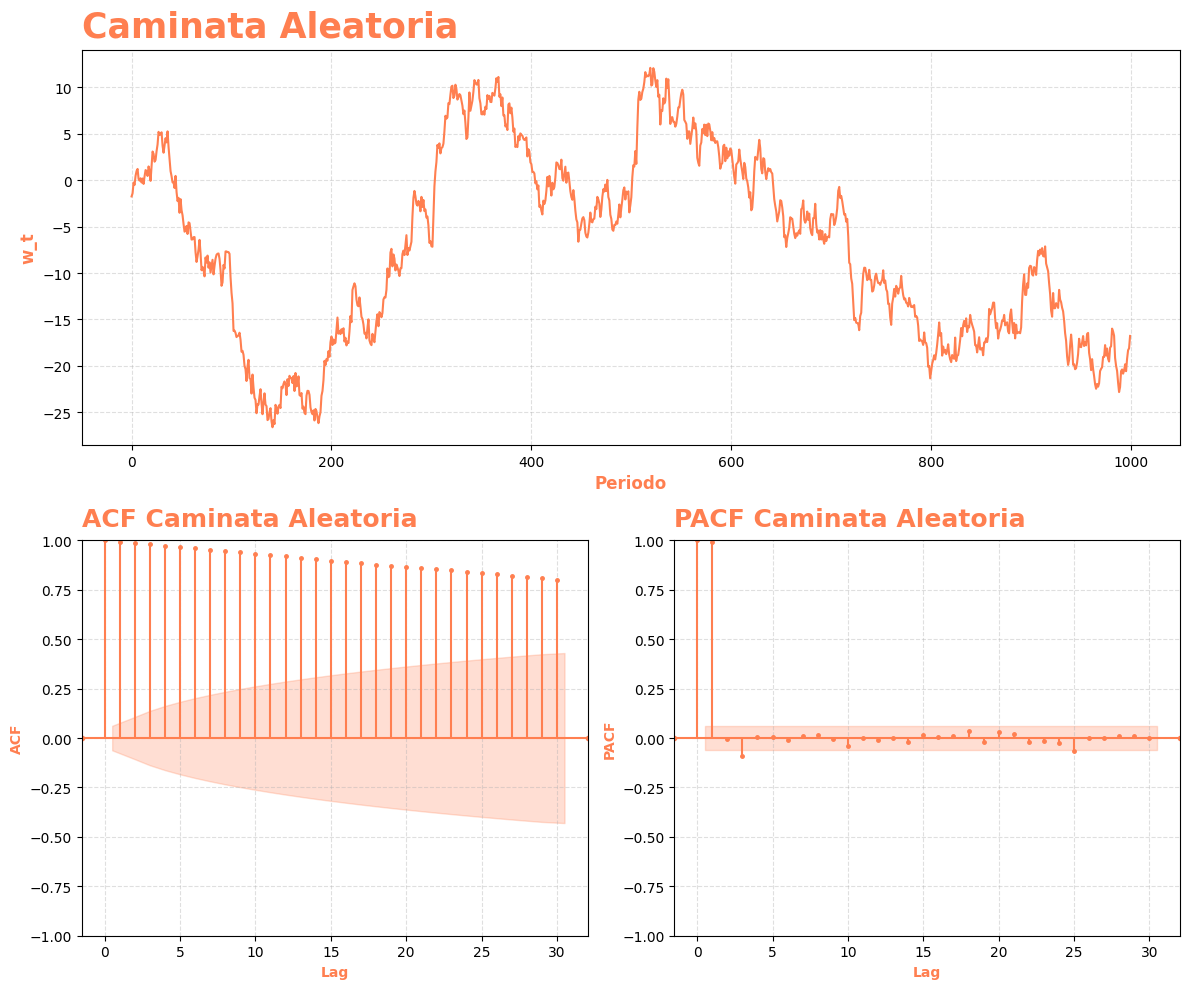

In [12]:
graphColor = 'coral'
modelo = 'walk'
nombre = 'Caminata Aleatoria'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
dfModelos[modelo].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('w_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(dfModelos[modelo], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(dfModelos[modelo], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

# **Caminata Aleatoria con Drift**

In [13]:
# Paso 1: Agregar el drift a cada componente de ruido blanco
drift = 0.05
dfModelos['drift'] = dfModelos['w'] + drift
display(dfModelos.head())

,w,walk,drift
0,-1.749765,-1.749765,-1.699765
1,0.342680,-1.407085,0.392680
2,1.153036,-0.254049,1.203036
3,-0.252436,-0.506485,-0.202436
4,0.981321,0.474835,1.031321


In [14]:
# Paso 2: Crear caminata con suma acumulativa
dfModelos['walk_drift'] = dfModelos['drift'].cumsum()
dfModelos.head(10)

,w,walk,drift,walk_drift
0,-1.749765,-1.749765,-1.699765,-1.699765
1,0.342680,-1.407085,0.392680,-1.307085
2,1.153036,-0.254049,1.203036,-0.104049
3,-0.252436,-0.506485,-0.202436,-0.306485
4,0.981321,0.474835,1.031321,0.724835
5,0.514219,0.989054,0.564219,1.289054
6,0.221180,1.210234,0.271180,1.560234
7,-1.070043,0.140191,-1.020043,0.540191
8,-0.189496,-0.049305,-0.139496,0.400695
9,0.255001,0.205696,0.305001,0.705696


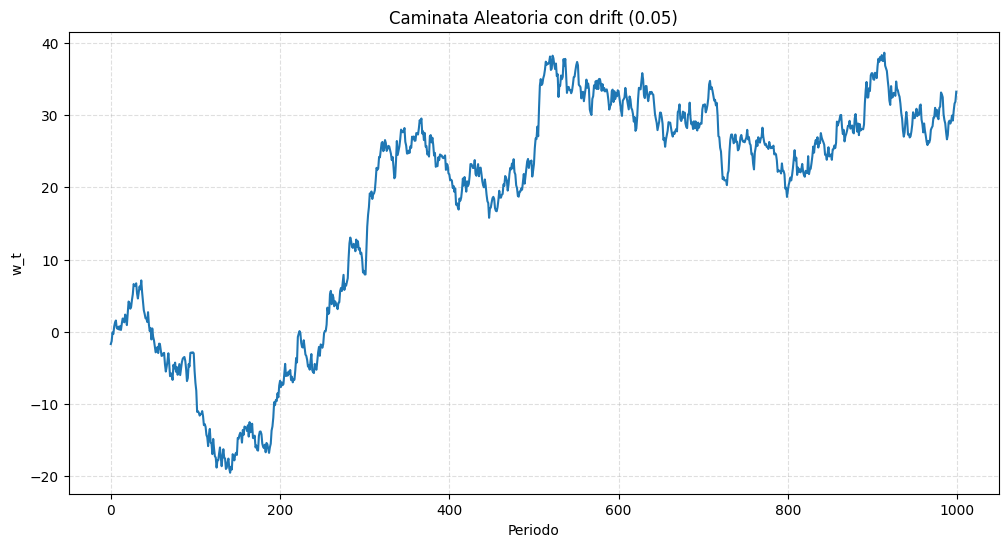

In [15]:
plt.figure(figsize=(12, 6))
dfModelos['walk_drift'].plot()

# Etiquetas
plt.title('Caminata Aleatoria con drift (' + str(drift) + ')')
plt.xlabel('Periodo')
plt.ylabel('w_t')

# Formato adicional
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

<Figure size 1200x600 with 0 Axes>

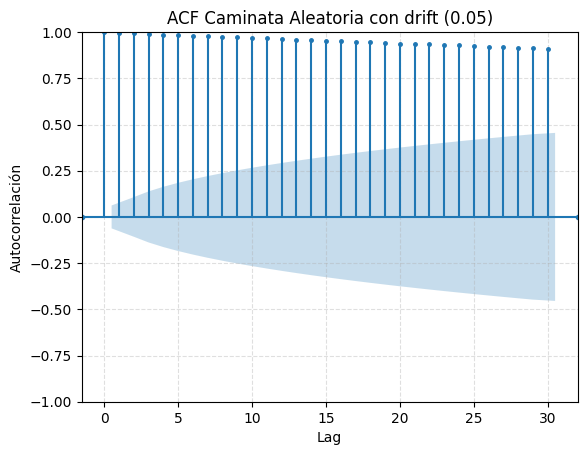

In [16]:
plt.figure(figsize=(12, 6))
# Gráfico de autocorrelación
plot_acf(dfModelos['walk_drift'], lags=30, marker = '.')

# Etiquetas
plt.title('ACF Caminata Aleatoria con drift (' + str(drift) + ')')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación')

# Formato
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

<Figure size 1200x600 with 0 Axes>

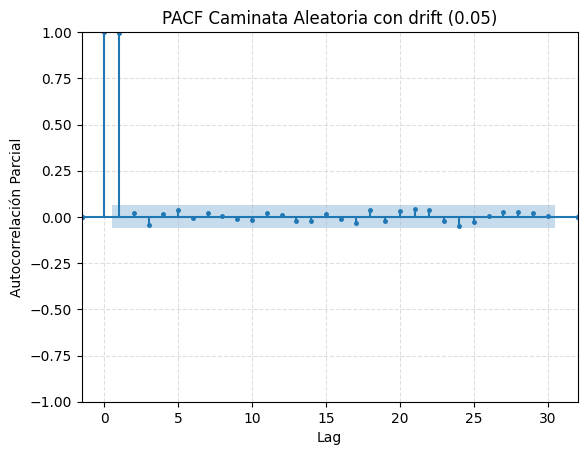

In [17]:
plt.figure(figsize=(12, 6))
# Gráfico de autocorrelación
plot_pacf(dfModelos['walk_drift'], lags=30, marker = '.')

# Etiquetas
plt.title('PACF Caminata Aleatoria con drift (' + str(drift) + ')')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')

# Formato
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

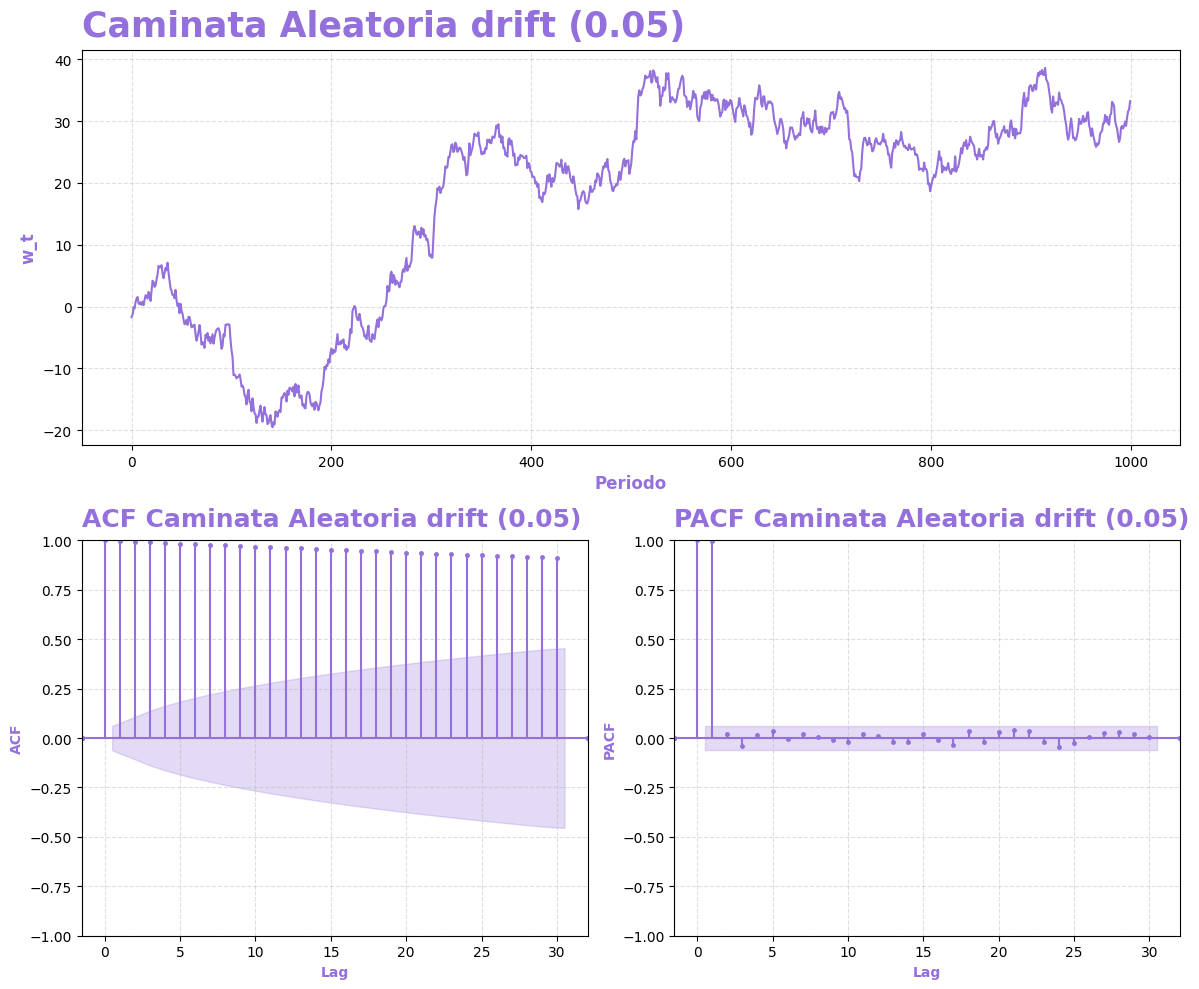

In [18]:
graphColor = 'mediumpurple'
modelo = 'walk_drift'
nombre = 'Caminata Aleatoria drift (' + str(drift) + ')'

# Crear nuestra figura con un GridSpec para acomodar los gráficos
fig = plt.figure(figsize=(12, 10)) # Tamaño de toda la figura
gs = fig.add_gridspec(2, 2) # Enrejado de 2 filas y 2 columnas

# Gráfico superior ocupando fila completa
ax0 = fig.add_subplot(gs[0, :]) # Subgráfico en la primera fila abarcando todas las columnas
dfModelos[modelo].plot(color = graphColor)
ax0.set_title(nombre, loc='left', color = graphColor, fontweight = 'bold', size = 25,  pad=10)
ax0.set_xlabel('Periodo', color = graphColor, fontweight = 'bold', size=12,)
ax0.set_ylabel('w_t', color = graphColor, fontweight = 'bold', size = 12)
ax0.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior izquierdo (ACF)
ax1 = fig.add_subplot(gs[1, 0]) # Subgráfico en la segunda fila primera columna
plot_acf(dfModelos[modelo], lags=30, marker = '.', title= '', ax=ax1, # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax1.collections[1]
ciACF.set_color(graphColor)
ax1.set_title('ACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax1.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax1.set_ylabel('ACF', color = graphColor, fontweight = 'bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Gráfico inferior derecho (PACF)
ax2 = fig.add_subplot(gs[1, 1])  # Subgráfico en la segunda fila segunda columna
plot_pacf(dfModelos[modelo], lags=30, marker = '.', title= '', ax=ax2,  # OJO con el parámetro ax
         color=graphColor, vlines_kwargs={"colors": graphColor})
# Cambio de color al intervalo de confianza
ciACF = ax2.collections[1]
ciACF.set_color(graphColor)
ax2.set_title('PACF ' + nombre, loc='left', color = graphColor, fontweight = 'bold', size = 18,  pad=10)
ax2.set_xlabel('Lag', color = graphColor, fontweight = 'bold')
ax2.set_ylabel('PACF', color = graphColor, fontweight = 'bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Prevenir traslape de etiquetas y títulos
plt.show()

# **Comparativos**

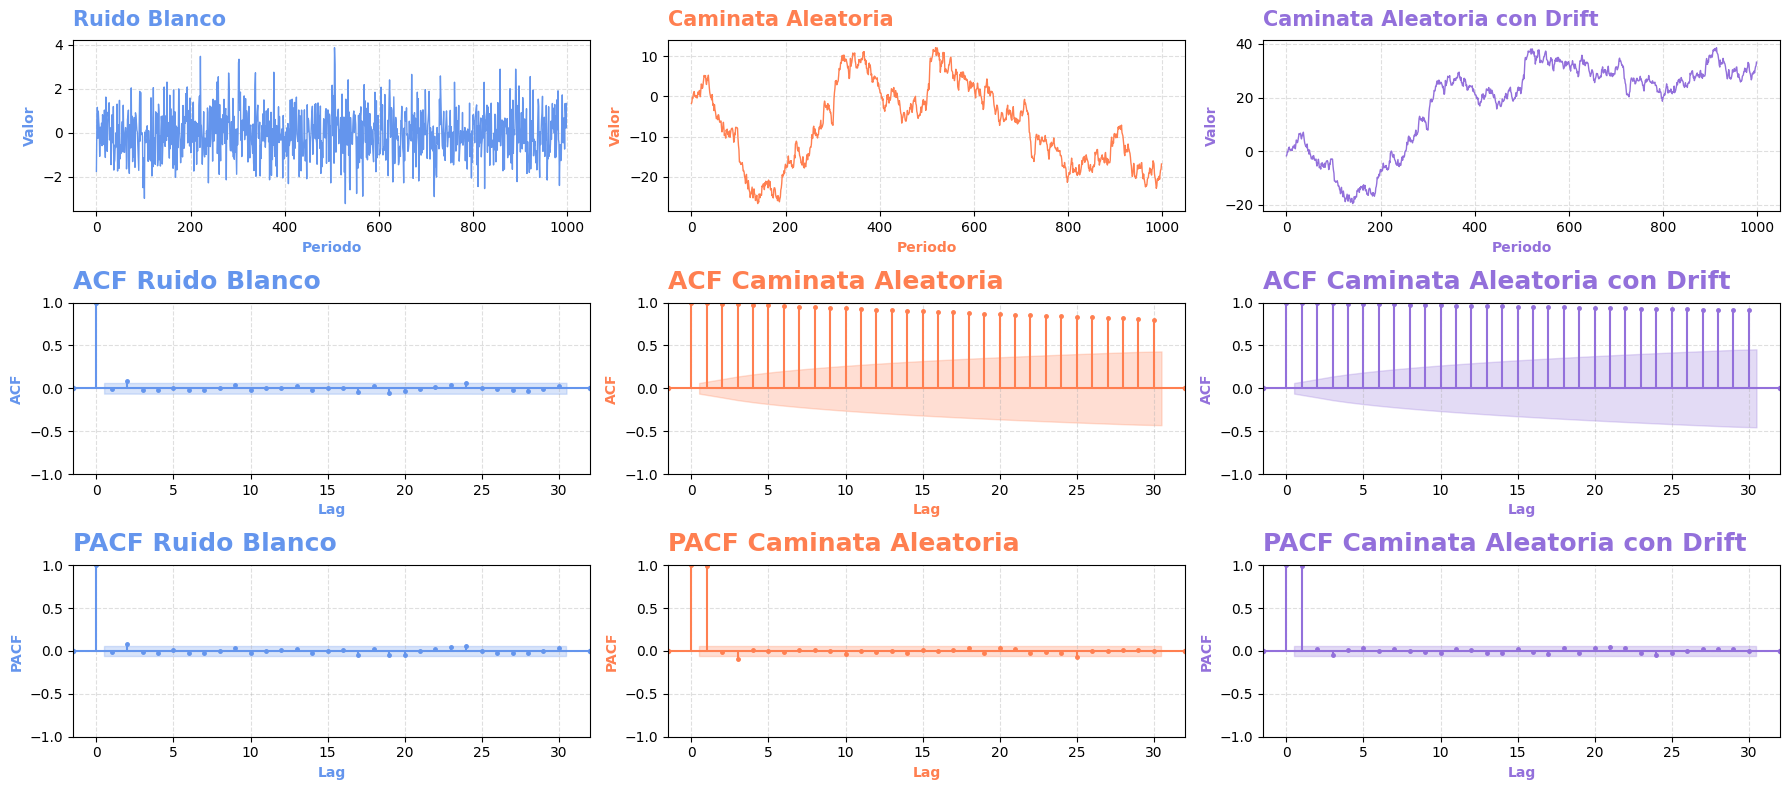

In [19]:
fig, axs = plt.subplots(3, 3, figsize=(18, 8))

modelos = ['w', 'walk', 'walk_drift']
nombresModelos = ['Ruido Blanco', 'Caminata Aleatoria', 'Caminata Aleatoria con Drift']
colores = ['cornflowerblue', 'coral', 'mediumpurple']

for i, modelo in enumerate(modelos):
    graphColor = colores[i]
    nombre = nombresModelos[i]

    # Fila 0: Serie de tiempo
    dfModelos[modelo].plot(ax=axs[0, i], color=graphColor, linewidth = 1)
    axs[0, i].set_title(nombre, loc='left', color=graphColor, fontweight='bold', size=15, pad=10)
    axs[0, i].set_xlabel('Periodo', color=graphColor, fontweight='bold')
    axs[0, i].set_ylabel('Valor', color=graphColor, fontweight='bold')
    axs[0, i].grid(True, linestyle='--', alpha=0.4)

    # Fila 1: ACF
    plot_acf(dfModelos[modelo], lags=30, marker='.', title='', ax=axs[1, i],
             color=graphColor, vlines_kwargs={"colors": graphColor})
    ciACF = axs[1, i].collections[1]
    ciACF.set_color(graphColor)
    axs[1, i].set_title('ACF ' + nombre, loc='left', color=graphColor, fontweight='bold', size=18, pad=10)
    axs[1, i].set_xlabel('Lag', color=graphColor, fontweight='bold')
    axs[1, i].set_ylabel('ACF', color=graphColor, fontweight='bold')
    axs[1, i].grid(True, linestyle='--', alpha=0.4)

    # Fila 2: PACF
    plot_pacf(dfModelos[modelo], lags=30, marker='.', title='', ax=axs[2, i],
              color=graphColor, vlines_kwargs={"colors": graphColor})
    ciACF = axs[2, i].collections[1]
    ciACF.set_color(graphColor)
    axs[2, i].set_title('PACF ' + nombre, loc='left', color=graphColor, fontweight='bold', size=18, pad=10)
    axs[2, i].set_xlabel('Lag', color=graphColor, fontweight='bold')
    axs[2, i].set_ylabel('PACF', color=graphColor, fontweight='bold')
    axs[2, i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()